# Sundarbans Mangrove Loss 1996 → 2020
Datenquelle: GMW v3 (Bunting et al. 2022)

In [1]:
from pathlib import Path
import geopandas as gpd

DATA_RAW = Path("..") / "data" / "raw"

gdf_1996 = gpd.read_file(DATA_RAW / "gmw_v3_1996" / "gmw_v3_1996_vec.shp")
gdf_2020 = gpd.read_file(DATA_RAW / "gmw_v3_2020" / "gmw_v3_2020_vec.shp")

print("1996:", len(gdf_1996), "Polygone, CRS:", gdf_1996.crs)
print("2020:", len(gdf_2020), "Polygone, CRS:", gdf_2020.crs)

1996: 1121419 Polygone, CRS: EPSG:4326
2020: 1076117 Polygone, CRS: EPSG:4326


Block 2 — Sundarbans Bbox und Crop

In [30]:
# Anpassung der Box (weiter nach Osten)
BBOX = (88.0, 21.3, 90.7, 23.0)  # (min_lon, min_lat, max_lon, max_lat)

sun_1996 = gdf_1996.cx[BBOX[0]:BBOX[2], BBOX[1]:BBOX[3]]
sun_2020 = gdf_2020.cx[BBOX[0]:BBOX[2], BBOX[1]:BBOX[3]]

print("Sundarbans 1996:", len(sun_1996), "Polygone")
print("Sundarbans 2020:", len(sun_2020), "Polygone")

Sundarbans 1996: 13069 Polygone
Sundarbans 2020: 7743 Polygone


Block 3 — Auf Equal-Area umprojizieren und Fläche berechnen

In [31]:
EQUAL_AREA_CRS = "EPSG:6933"  # World Cylindrical Equal Area, Einheit: Meter

sun_1996_ea = sun_1996.to_crs(EQUAL_AREA_CRS)
sun_2020_ea = sun_2020.to_crs(EQUAL_AREA_CRS)

area_1996_km2 = sun_1996_ea.geometry.area.sum() / 1_000_000
area_2020_km2 = sun_2020_ea.geometry.area.sum() / 1_000_000
loss_km2 = area_1996_km2 - area_2020_km2

print(f"Fläche 1996: {area_1996_km2:,.1f} km²")
print(f"Fläche 2020: {area_2020_km2:,.1f} km²")
print(f"Verlust:     {loss_km2:,.1f} km²")

Fläche 1996: 6,313.3 km²
Fläche 2020: 6,293.2 km²
Verlust:     20.1 km²


In [32]:
area_1996_wrong = sun_1996.geometry.area.sum()  # keine Umprojektion!

print(f"Fläche in Grad²:    {area_1996_wrong:.4f}")
print(f"Fläche in km²:      {area_1996_km2:,.1f}  (korrekt, EPSG:6933)")
print(f"Faktor:             {area_1996_km2 / area_1996_wrong:,.0f}x Unterschied")

Fläche in Grad²:    0.5521
Fläche in km²:      6,313.3  (korrekt, EPSG:6933)
Faktor:             11,435x Unterschied


In [33]:
print("Bbox definiert:  ", BBOX)
print("sun_1996 bounds: ", sun_1996.total_bounds.round(3))
print("sun_2020 bounds: ", sun_2020.total_bounds.round(3))

Bbox definiert:   (88.0, 21.3, 90.7, 23.0)
sun_1996 bounds:  [88.    21.537 90.704 22.503]
sun_2020 bounds:  [88.    21.547 90.702 22.503]


In [34]:
print("sun_1996 bounds: ", sun_1996.total_bounds.round(3))

sun_1996 bounds:  [88.    21.537 90.704 22.503]


# Start mit Matplotlib

In [35]:
# Python-Bibliothek für statische Grafiken. Erzeugt PNG/PDF-Bilder — kein Browser nötig. 
# Volle Kontrolle über jeden Pixel. Gut für: Exports, Reports, Streamlit-App (als Bild einbetten).

In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import box

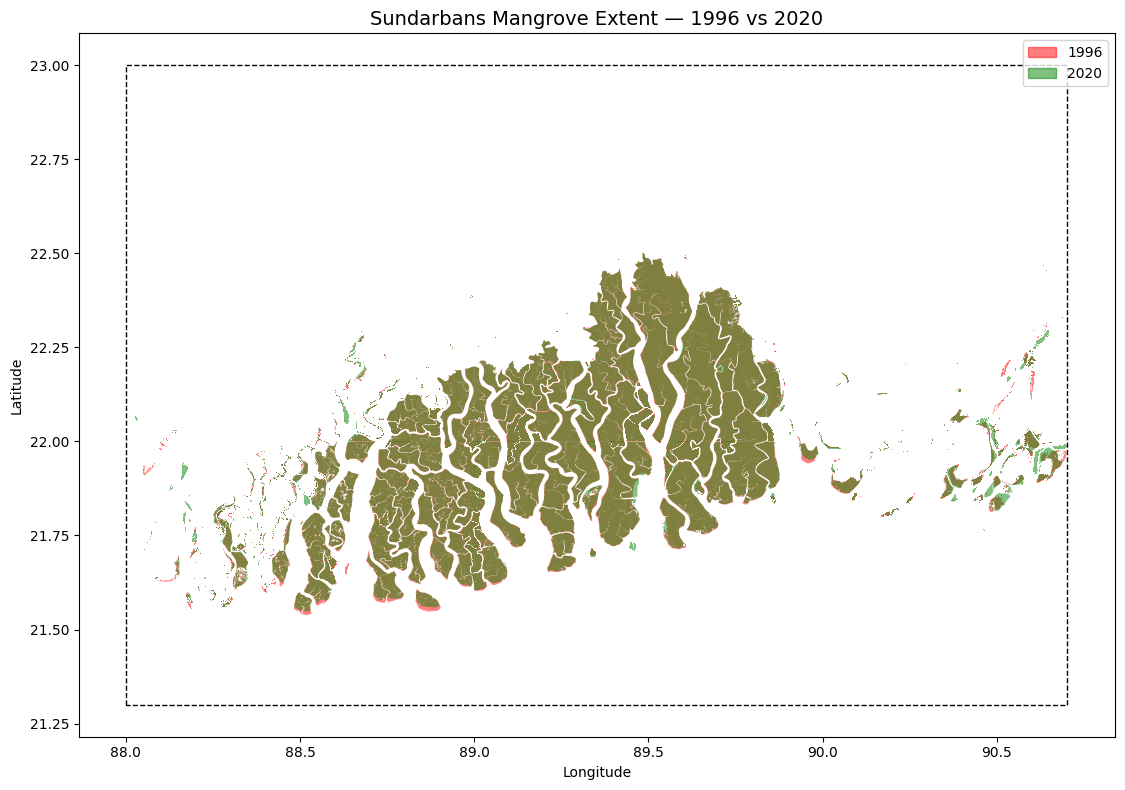

In [37]:
fig, ax = plt.subplots(figsize=(12, 8))

sun_1996.plot(ax=ax, color="red",   alpha=0.5, linewidth=0)
sun_2020.plot(ax=ax, color="green", alpha=0.5, linewidth=0)

bbox_geom = gpd.GeoDataFrame(geometry=[box(*BBOX)],
crs="EPSG:4326")
bbox_geom.boundary.plot(ax=ax, color="black", linewidth=1,
linestyle="--")

ax.set_title("Sundarbans Mangrove Extent — 1996 vs 2020",
fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

patch_1996 = mpatches.Patch(color="red",   alpha=0.5,
label="1996")
patch_2020 = mpatches.Patch(color="green", alpha=0.5,
label="2020")
ax.legend(handles=[patch_1996, patch_2020])

plt.tight_layout()
plt.savefig("../assets/precomputed/sundarbans_matplotlib.png",
dpi=150)
plt.show()

# Leafmap

In [38]:
# Baut interaktive Karten im Jupyter-Browser. Du kannst zoomen, 
# Layer ein-/ausblenden, auf Polygone klicken. Wrappt 
# folium — kann GeoDataFrames, GeoTIFFs, STAC-Daten direkt anzeigen
# ohne Konvertierung. Gut für: Exploration im  Notebook.

In [39]:
import leafmap

In [40]:
# hat nicht funktioniert, da eine Extenion fehlt, deswegen unten mit foliummap.Map anstatt leafmap.Map
# m = leafmap.Map(center=[22.0, 89.3], zoom=8)

#m.add_gdf(sun_1996, layer_name="1996", style={"color": "red",
#   "fillOpacity": 0.4, "weight": 0})
#m.add_gdf(sun_2020, layer_name="2020", style={"color":
#  "green", "fillOpacity": 0.4, "weight": 0})

#m

In [41]:
#from IPython.display import display
#display(m)

In [42]:
from leafmap import foliumap
m = foliumap.Map(center=[22.0, 89.3], zoom=8)
m.add_gdf(sun_1996, layer_name="1996", style={"color": "red",
   "fillOpacity": 0.4, "weight": 0})
m.add_gdf(sun_2020, layer_name="2020", style={"color":
  "green", "fillOpacity": 0.4, "weight": 0})
m.to_html("../assets/precomputed/sundarbans_leafmap.html")
print("Gespeichert.")

Gespeichert.


 # Bbox-Stand prüfen

In [43]:
print("Aktuelle BBOX:", BBOX)
print(f"Fläche 1996: {area_1996_km2:,.1f} km²")
print(f"Fläche 2020: {area_2020_km2:,.1f} km²")
print(f"Verlust:     {area_1996_km2 - area_2020_km2:,.1f} km²")

Aktuelle BBOX: (88.0, 21.3, 90.7, 23.0)
Fläche 1996: 6,313.3 km²
Fläche 2020: 6,293.2 km²
Verlust:     20.1 km²


# Carbon Berechnung

In [49]:
CARBON_DENSITY_T_PER_HA = 1000   # t CO₂e/ha, Sanderman et al. 2018
BLUE_CARBON_PRICE_USD   = 30     # $/t CO₂e, Voluntary Carbon Market

In [50]:
loss_km2    = area_1996_km2 - area_2020_km2
loss_ha     = loss_km2 * 100
carbon_loss = loss_ha * CARBON_DENSITY_T_PER_HA
market_value = carbon_loss * BLUE_CARBON_PRICE_USD

print(f"Netto-Verlust:      {loss_km2:,.1f} km²")
print(f"Verlust in Hektar:  {loss_ha:,.0f} ha")
print(f"Carbon-Loss:        {carbon_loss:,.0f} t CO₂e")
print(f"Marktwert:          ${market_value:,.0f}")

Netto-Verlust:      20.1 km²
Verlust in Hektar:  2,006 ha
Carbon-Loss:        2,006,150 t CO₂e
Marktwert:          $60,184,505
